In [76]:
import pandas as pd
import plotly.express as px

In [77]:
nav = pd.read_csv("../data/processed/nav_history_clean.csv")

In [78]:
nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [79]:
nav['date'] = pd.to_datetime(nav['date'])

In [80]:
sample_funds = nav['amfi_code'].unique()[:5]

print(sample_funds)

[100016 100025 100033 101206 101207]


In [81]:
plot_data = nav[
    nav['amfi_code'].isin(sample_funds)
]

plot_data.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [82]:
fig = px.line(
    plot_data,
    x='date',
    y='nav',
    color='amfi_code',
    title='NAV Trend Analysis'
)

fig.show()

In [83]:
fig.write_image(
    "../reports/charts/nav_trend.png"
)

KeyboardInterrupt: 

## Insight 1

The selected mutual fund schemes show an overall upward NAV trend during the analysis period.

In [ ]:
aum=pd.read_csv("C:\\Users\\ABHILASH\\mutual_fund_project\\data\\raw\\03_aum_by_fund_house.csv")

In [ ]:
print(aum.columns)

Index(['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes'], dtype='object')


In [ ]:
aum.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,SBI Mutual Fund,6.05,605000,186
1,2022-03-31,ICICI Prudential MF,4.65,465000,216
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195
3,2022-03-31,Nippon India MF,2.70,270000,177
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168


In [ ]:
latest_aum = (
    aum.sort_values('date')
       .groupby('fund_house')
       .tail(1)
)

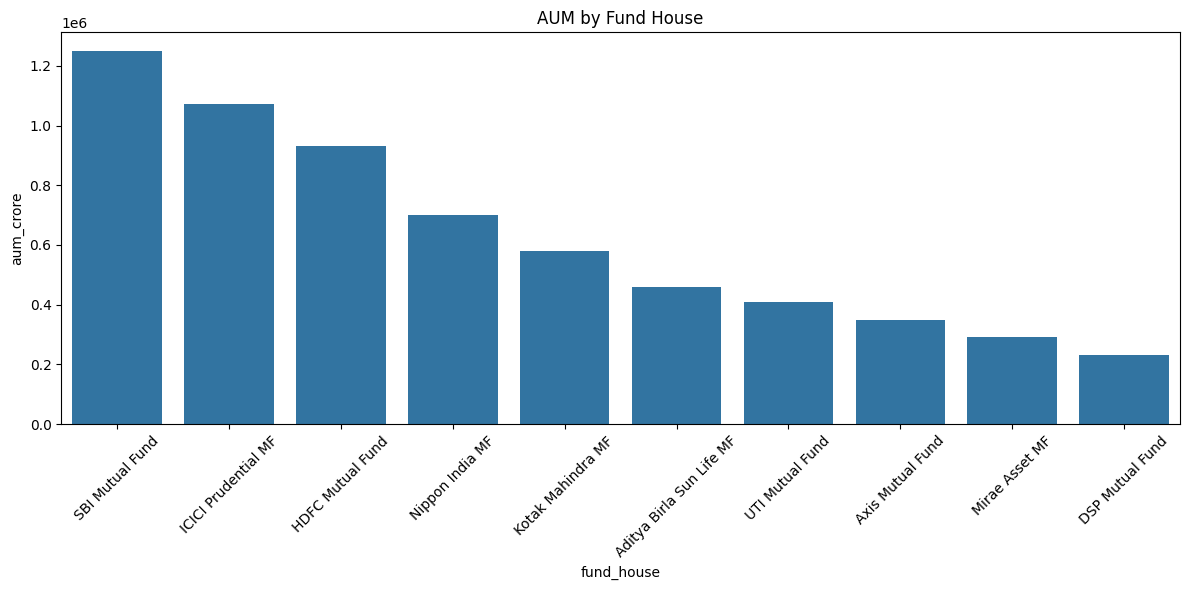

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

sns.barplot(
    data=latest_aum.sort_values(
        'aum_crore',
        ascending=False
    ),
    x='fund_house',
    y='aum_crore'
)

plt.xticks(rotation=45)

plt.title("AUM by Fund House")

plt.tight_layout()

plt.show()

In [ ]:
aum['date'] = pd.to_datetime(aum['date'])

In [ ]:
import os

os.makedirs(
    "../reports/charts",
    exist_ok=True
)

In [ ]:
plt.savefig(
    "../reports/charts/aum_growth.png",
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

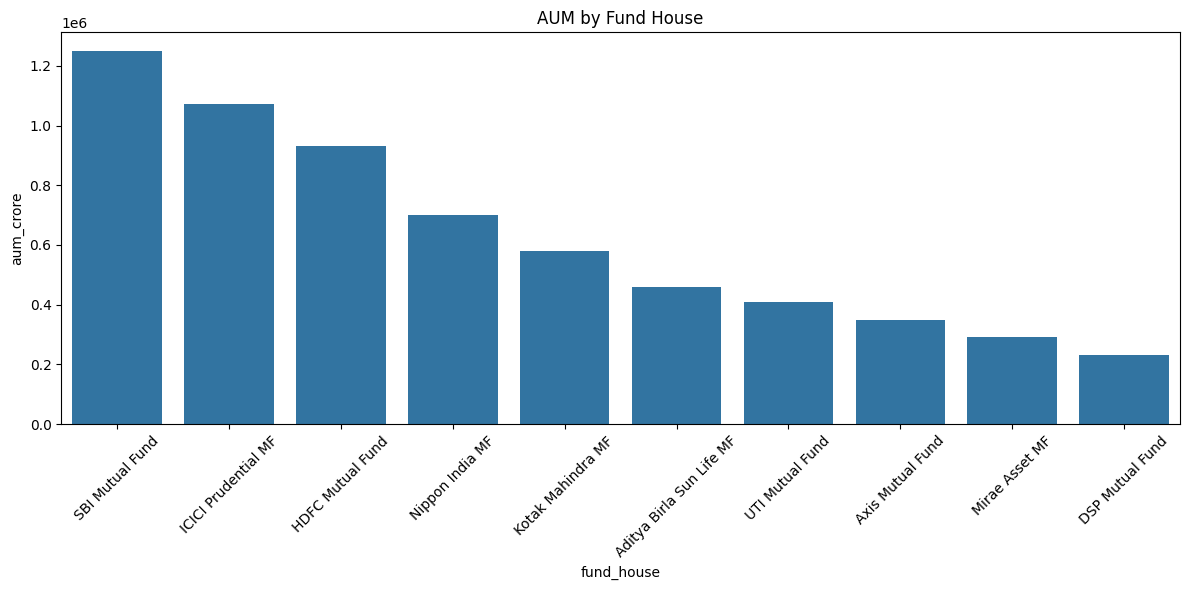

In [ ]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=latest_aum.sort_values(
        'aum_crore',
        ascending=False
    ),
    x='fund_house',
    y='aum_crore'
)

plt.xticks(rotation=45)

plt.title("AUM by Fund House")

plt.tight_layout()

plt.savefig(
    "../reports/charts/aum_growth.png",
    bbox_inches="tight"
)

plt.show()

In [ ]:
sip = pd.read_csv("C:\\Users\\ABHILASH\\mutual_fund_project\\data\\raw\\04_monthly_sip_inflows.csv")

In [ ]:
print(sip.columns)
sip.head()

Index(['month', 'sip_inflow_crore', 'active_sip_accounts_crore',
       'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct'],
      dtype='object')


,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01,11517,4.91,9.10,4.80,NaN
1,2022-02,11438,4.93,8.20,4.85,NaN
2,2022-03,12328,5.09,10.50,5.01,NaN
3,2022-04,11863,5.48,9.52,5.12,NaN
4,2022-05,12286,5.55,8.10,5.15,NaN


In [ ]:
sip['month'] = pd.to_datetime(sip['month'])

In [ ]:
import plotly.express as px

fig = px.line(
    sip,
    x='month',
    y='sip_inflow_crore',
    title='Monthly SIP Inflow Trend (2022-2025)',
    markers=True
)

fig.show()

In [ ]:
peak = sip.loc[sip['sip_inflow_crore'].idxmax()]

print(peak)

month                        2025-12-01 00:00:00
sip_inflow_crore                           31002
active_sip_accounts_crore                   9.35
new_sip_accounts_lakh                        9.8
sip_aum_lakh_crore                          15.9
yoy_growth_pct                             17.17
Name: 47, dtype: object


In [ ]:
import plotly.express as px

fig = px.line(
    sip,
    x='month',
    y='sip_inflow_crore',
    title='Monthly SIP Inflow Trend (2022-2025)',
    markers=True
)

peak = sip.loc[sip['sip_inflow_crore'].idxmax()]

fig.add_annotation(
    x=str(peak['month'].date()),
    y=peak['sip_inflow_crore'],
    text=f"Peak: ₹{peak['sip_inflow_crore']} Cr",
    showarrow=True
)

fig.show()

In [ ]:
fig.write_image(
    "C:\\Users\\ABHILASH\\mutual_fund_project\\reports\\charts\\sip_inflow.png"
)

In [ ]:
category = pd.read_csv("C:\\Users\\ABHILASH\\mutual_fund_project\\data\\raw\\05_category_inflows.csv")

In [ ]:
category.head()

,month,category,net_inflow_crore
0,2024-04,Large Cap,2413.0
1,2024-04,Mid Cap,3897.0
2,2024-04,Small Cap,3533.0
3,2024-04,Flexi Cap,4947.0
4,2024-04,Large & Mid Cap,4214.0


In [ ]:
category['month'] = pd.to_datetime(category['month'])

In [ ]:
heatmap_data = category.pivot(
    index='category',
    columns='month',
    values='net_inflow_crore'
)

In [ ]:
heatmap_data.head()

month,2024-04-01,2024-05-01,2024-06-01,2024-07-01,2024-08-01,2024-09-01,2024-10-01,2024-11-01,2024-12-01,2025-01-01,2025-02-01,2025-03-01
category,,,,,,,,,,,,
ELSS,466.0,553.0,472.0,471.0,499.0,537.0,537.0,571.0,521.0,516.0,437.0,500.0
Flexi Cap,4947.0,5529.0,4478.0,4869.0,5562.0,5397.0,6004.0,6111.0,4654.0,5603.0,6068.0,4767.0
Gilt,784.0,836.0,864.0,959.0,952.0,925.0,898.0,704.0,831.0,744.0,942.0,956.0
Hybrid,2955.0,3487.0,3163.0,3291.0,3684.0,3015.0,3314.0,3264.0,3538.0,2967.0,3360.0,2830.0
Large & Mid Cap,4214.0,4368.0,4610.0,5023.0,5411.0,4528.0,4581.0,5556.0,4878.0,4816.0,5524.0,4243.0


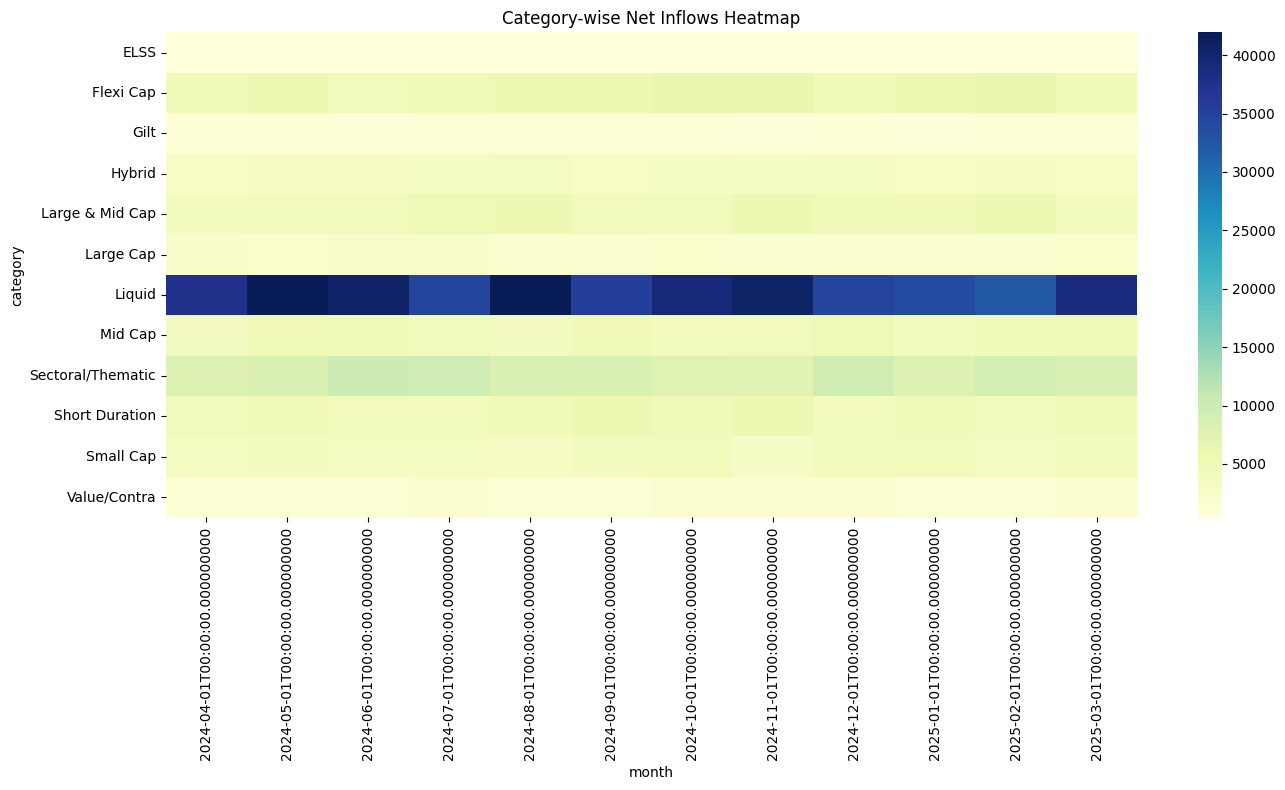

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,8))

sns.heatmap(
    heatmap_data,
    cmap='YlGnBu',
    annot=False
)

plt.title("Category-wise Net Inflows Heatmap")

plt.tight_layout()

plt.show()

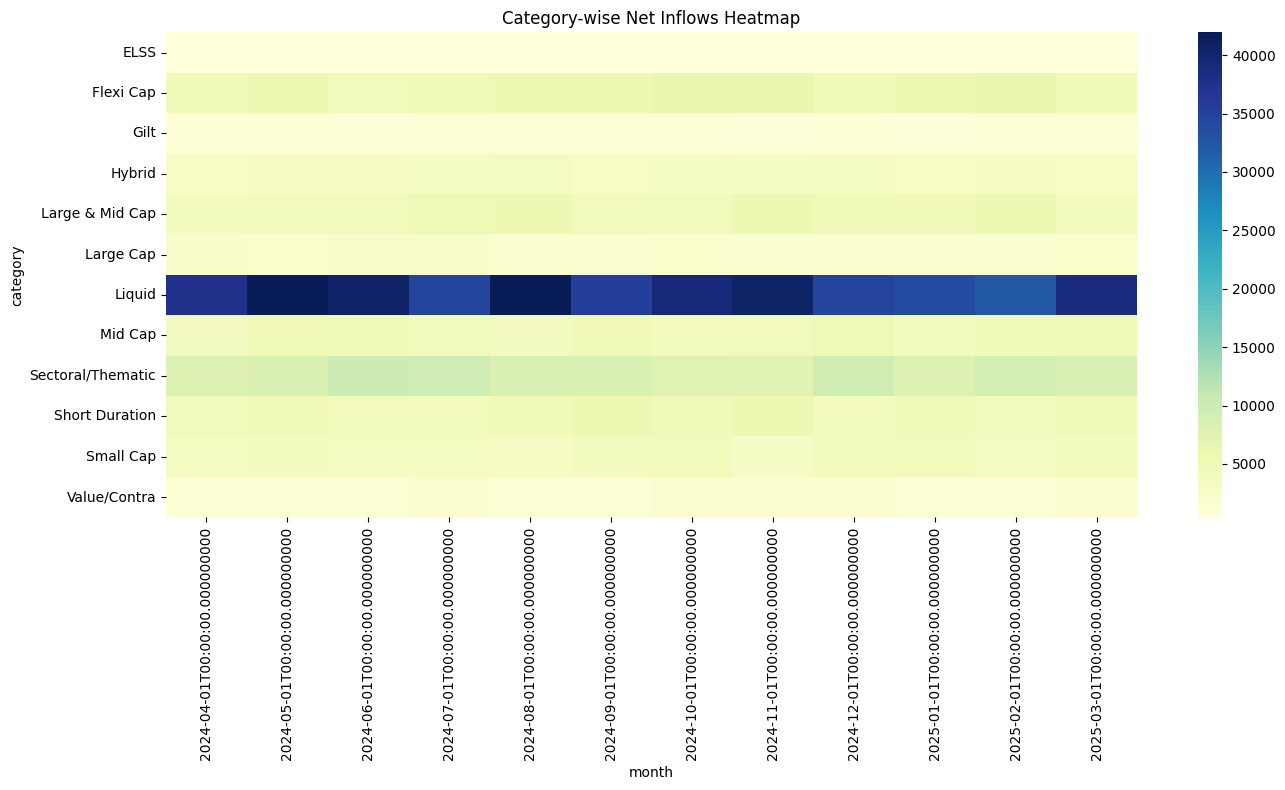

In [ ]:
plt.figure(figsize=(14,8))

sns.heatmap(
    heatmap_data,
    cmap='YlGnBu',
    annot=False
)

plt.title("Category-wise Net Inflows Heatmap")

plt.tight_layout()

plt.savefig(
    "C:\\Users\\ABHILASH\\mutual_fund_project\\reports\\charts\\category_heatmap.png",
    bbox_inches="tight"
)

plt.show()

## Insight 4

Mid Cap, Small Cap, and Flexi Cap categories consistently attracted strong investor inflows, indicating higher risk appetite among investors.

In [ ]:
txn=pd.read_csv("C:\\Users\\ABHILASH\\mutual_fund_project\\data\\raw\\08_investor_transactions.csv")

In [ ]:
print(txn.columns)

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='object')


In [ ]:
age_counts = txn['age_group'].value_counts()

print(age_counts)

age_group
26-35    13463
36-45     8146
18-25     4916
46-55     3779
56+       2474
Name: count, dtype: int64


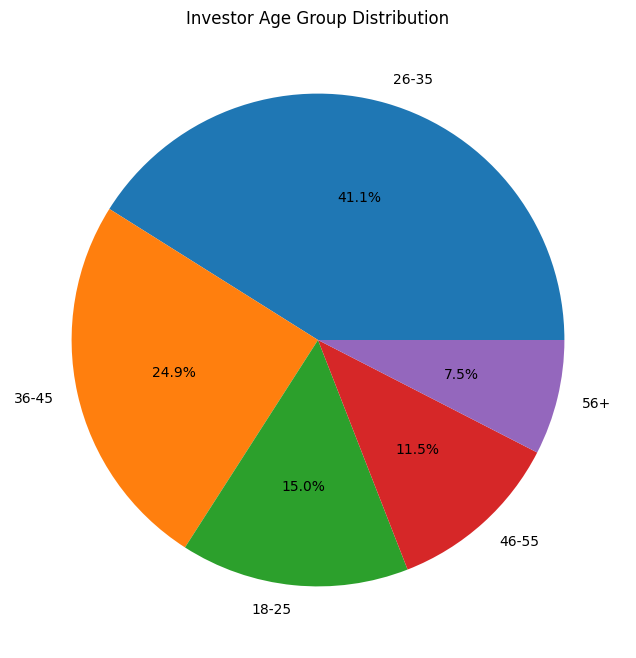

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))

plt.pie(
    age_counts,
    labels=age_counts.index,
    autopct='%1.1f%%'
)

plt.title("Investor Age Group Distribution")

plt.savefig(
    "../reports/charts/age_group_distribution.png",
    bbox_inches="tight"
)

plt.show()

## Insight 5

The majority of investors belong to the working-age population, indicating strong participation from salaried and early-career investors.

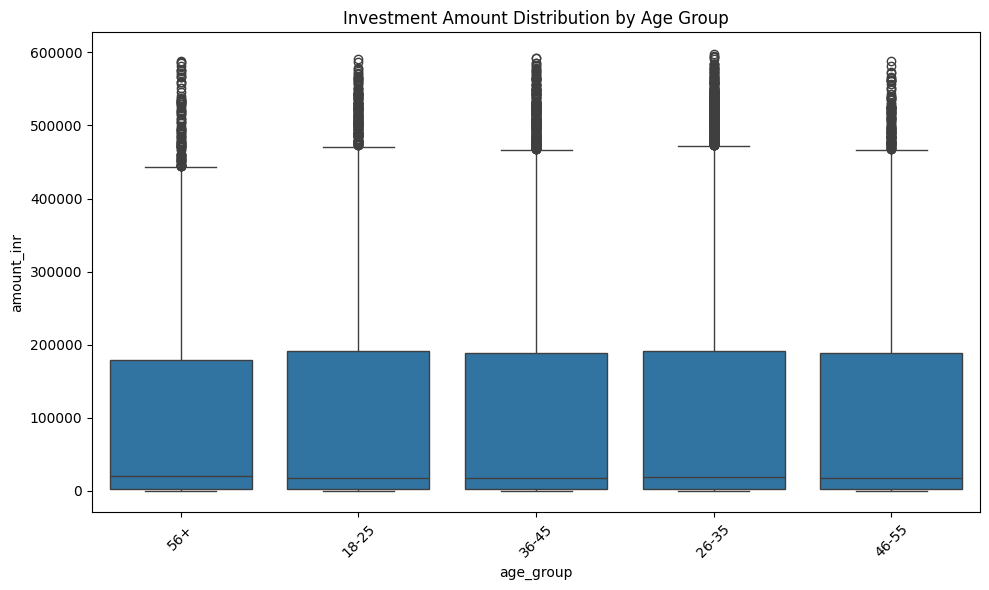

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.boxplot(
    data=txn,
    x='age_group',
    y='amount_inr'
)

plt.title("Investment Amount Distribution by Age Group")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "../reports/charts/amount_boxplot_age_group.png",
    bbox_inches="tight"
)

plt.show()

## Insight 6

Investment amounts vary significantly across age groups, with some age segments contributing higher-value transactions.

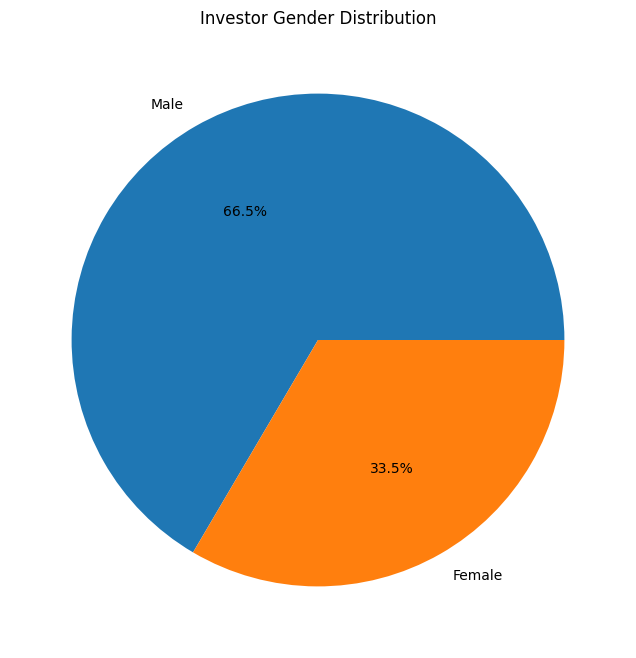

In [ ]:
gender_counts = txn['gender'].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct='%1.1f%%'
)

plt.title("Investor Gender Distribution")

plt.savefig(
    "../reports/charts/gender_distribution.png",
    bbox_inches="tight"
)

plt.show()

## Insight 7

The investor base shows participation from multiple genders, providing a diversified customer profile.

In [ ]:
state_data = (
    txn.groupby('state')['amount_inr']
       .sum()
       .sort_values(ascending=False)
       .head(15)
)

print(state_data)

state
Punjab            315780459
Tamil Nadu        315177237
Madhya Pradesh    308312493
Rajasthan         298645822
Gujarat           298358940
West Bengal       297182514
Telangana         290219284
Delhi             289633404
Uttar Pradesh     285368873
Haryana           279634354
Karnataka         273753570
Maharashtra       269513480
Name: amount_inr, dtype: int64


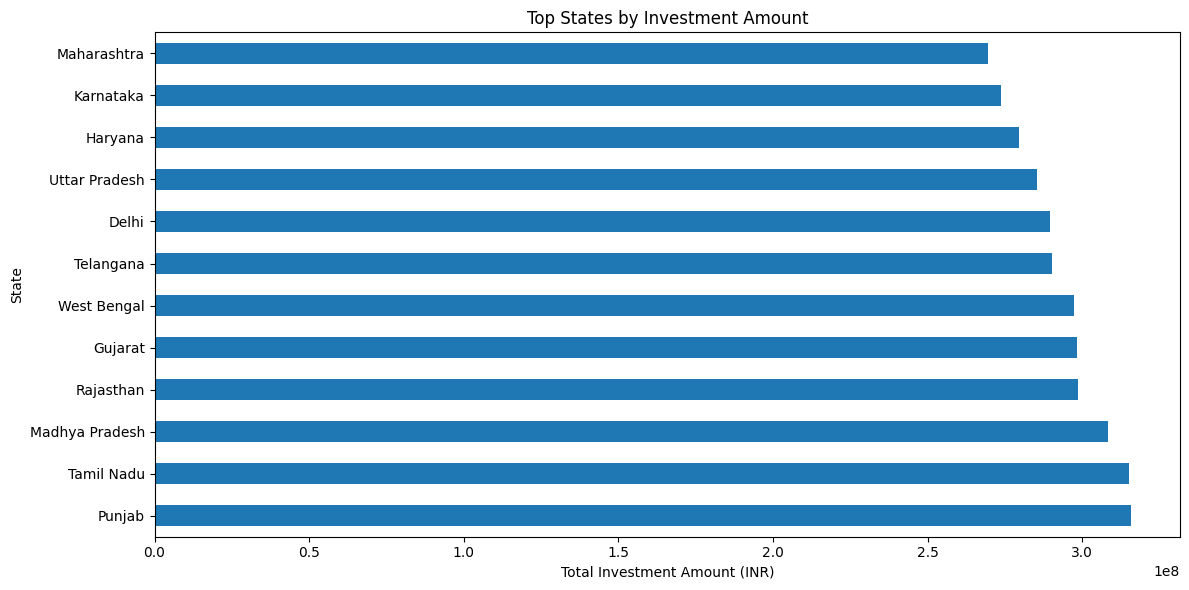

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

state_data.plot(kind='barh')

plt.title("Top States by Investment Amount")
plt.xlabel("Total Investment Amount (INR)")
plt.ylabel("State")

plt.tight_layout()

plt.savefig(
    "../reports/charts/state_investment_distribution.png",
    bbox_inches="tight"
)

plt.show()

## Insight 8

A small number of states contribute a significant share of total investment volume, indicating geographic concentration of mutual fund participation.

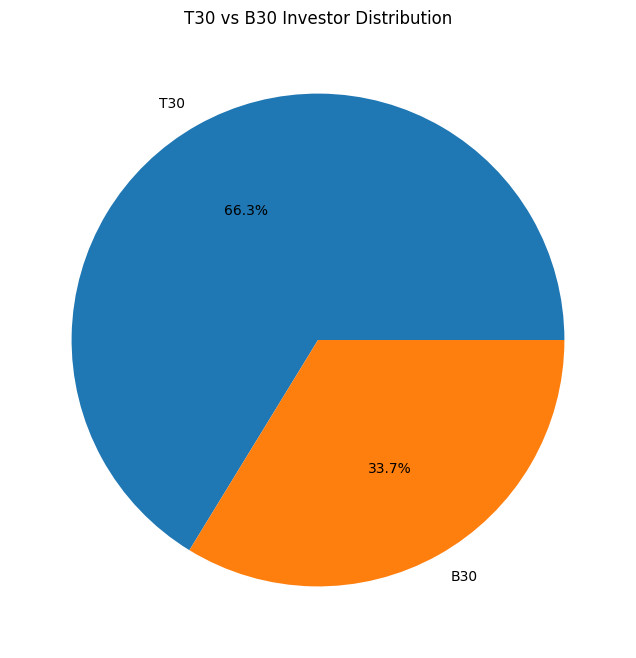

In [ ]:
tier_counts = txn['city_tier'].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    tier_counts,
    labels=tier_counts.index,
    autopct='%1.1f%%'
)

plt.title("T30 vs B30 Investor Distribution")

plt.savefig(
    "../reports/charts/t30_b30_distribution.png",
    bbox_inches="tight"
)

plt.show()

## Insight 9

Investor participation is expanding beyond major metropolitan cities, reflecting deeper mutual fund penetration across India.

In [ ]:
folio = pd.read_csv("C:/Users/ABHILASH/mutual_fund_project/data/raw/06_industry_folio_count.csv")

In [ ]:
print(folio.columns)
folio.head()

Index(['month', 'total_folios_crore', 'equity_folios_crore',
       'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore'],
      dtype='object')


,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
0,2022-01,13.26,9.28,1.86,0.80,1.33
1,2022-04,13.91,9.74,1.95,0.83,1.39
2,2022-07,13.85,9.69,1.94,0.83,1.38
3,2022-10,14.12,9.88,1.98,0.85,1.41
4,2023-01,14.81,10.37,2.07,0.89,1.48


In [ ]:
folio['month'] = pd.to_datetime(folio['month'])

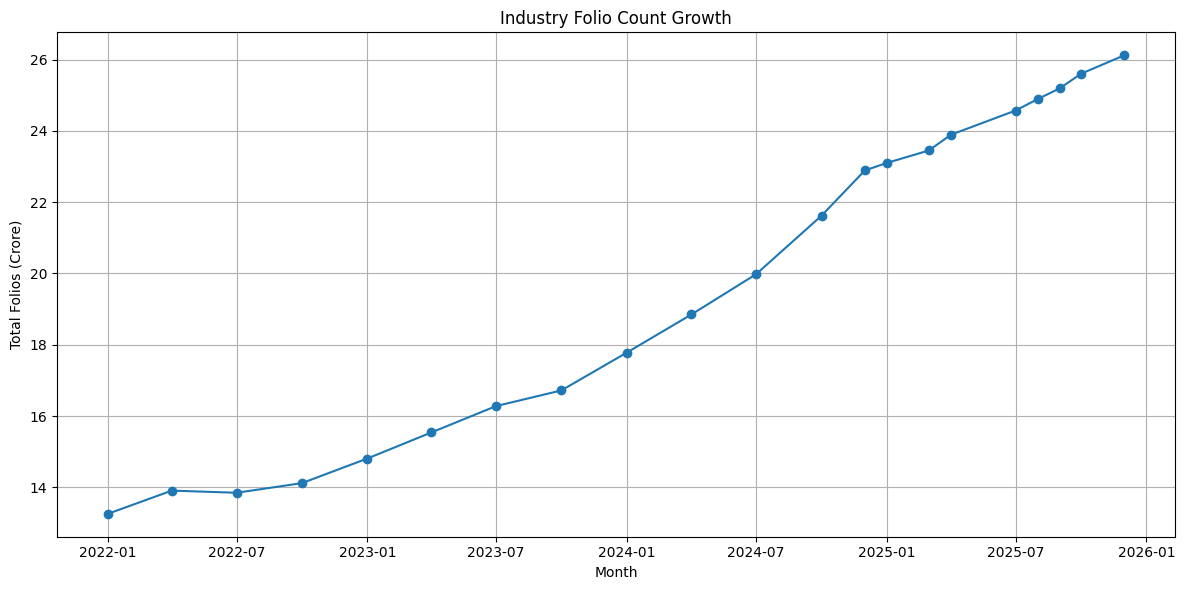

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(
    folio['month'],
    folio['total_folios_crore'],
    marker='o'
)

plt.title("Industry Folio Count Growth")
plt.xlabel("Month")
plt.ylabel("Total Folios (Crore)")

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "../reports/charts/folio_growth.png",
    bbox_inches="tight"
)

plt.show()

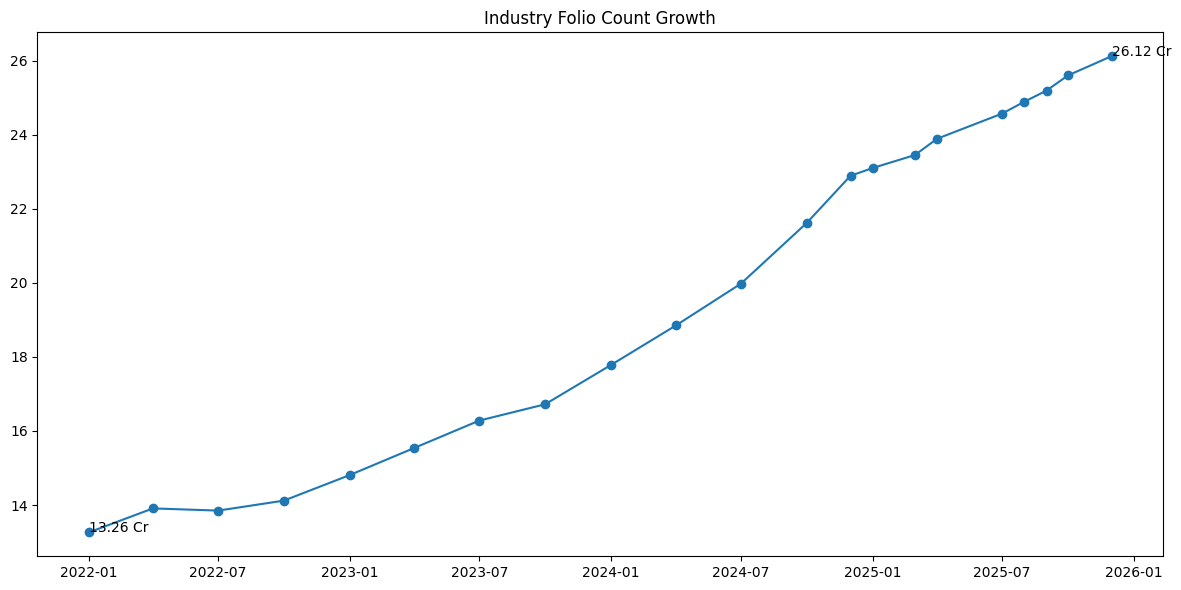

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(
    folio['month'],
    folio['total_folios_crore'],
    marker='o'
)

plt.annotate(
    "13.26 Cr",
    (folio['month'].iloc[0],
     folio['total_folios_crore'].iloc[0])
)

plt.annotate(
    f"{folio['total_folios_crore'].iloc[-1]} Cr",
    (folio['month'].iloc[-1],
     folio['total_folios_crore'].iloc[-1])
)

plt.title("Industry Folio Count Growth")

plt.tight_layout()

plt.savefig(
    "../reports/charts/folio_growth.png",
    bbox_inches="tight"
)

plt.show()

## Insight 10

Total mutual fund folios increased steadily over the analysis period, reflecting growing retail participation and financialization of household savings.

In [ ]:
print(nav.head())
print(nav.columns)

   amfi_code       date       nav
0     100016 2022-01-03  520.4608
1     100016 2022-01-04  515.0971
2     100016 2022-01-05  521.7239
3     100016 2022-01-06  515.7880
4     100016 2022-01-07  515.1639
Index(['amfi_code', 'date', 'nav'], dtype='object')


In [ ]:
sample_funds = nav['amfi_code'].unique()[:10]

nav_sample = nav[
    nav['amfi_code'].isin(sample_funds)
]

In [ ]:
nav_pivot = nav_sample.pivot(
    index='date',
    columns='amfi_code',
    values='nav'
)

In [ ]:
nav_pivot.head()

amfi_code,100016,100025,100033,101206,101207,101208,102885,102886,102887,118632
date,,,,,,,,,,
2022-01-03,520.4608,26.3169,107.3758,305.0996,38.5736,310.7415,89.8728,119.2905,191.0721,42.8339
2022-01-04,515.0971,26.2234,105.9447,305.4514,38.1545,310.6977,90.8724,120.6402,189.0737,42.8033
2022-01-05,521.7239,26.2221,105.4800,306.6324,38.1775,310.8165,90.1565,121.4580,188.0701,43.0564
2022-01-06,515.7880,26.1728,104.9350,305.9800,37.0665,310.7719,91.5338,125.2386,190.4545,43.2088
2022-01-07,515.1639,26.2261,104.3318,304.0480,37.9845,310.8388,90.6762,124.1321,187.3124,42.9585


In [ ]:
nav_pivot.head()

amfi_code,100016,100025,100033,101206,101207,101208,102885,102886,102887,118632
date,,,,,,,,,,
2022-01-03,520.4608,26.3169,107.3758,305.0996,38.5736,310.7415,89.8728,119.2905,191.0721,42.8339
2022-01-04,515.0971,26.2234,105.9447,305.4514,38.1545,310.6977,90.8724,120.6402,189.0737,42.8033
2022-01-05,521.7239,26.2221,105.4800,306.6324,38.1775,310.8165,90.1565,121.4580,188.0701,43.0564
2022-01-06,515.7880,26.1728,104.9350,305.9800,37.0665,310.7719,91.5338,125.2386,190.4545,43.2088
2022-01-07,515.1639,26.2261,104.3318,304.0480,37.9845,310.8388,90.6762,124.1321,187.3124,42.9585


In [84]:
returns = nav_pivot.pct_change()
returns.head()

amfi_code,100016,100025,100033,101206,101207,101208,102885,102886,102887,118632
date,,,,,,,,,,
2022-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-01-04,-0.010306,-0.003553,-0.013328,0.001153,-0.010865,-0.000141,0.011122,0.011314,-0.010459,-0.000714
2022-01-05,0.012865,-0.000050,-0.004386,0.003866,0.000603,0.000382,-0.007878,0.006779,-0.005308,0.005913
2022-01-06,-0.011377,-0.001880,-0.005167,-0.002128,-0.029101,-0.000143,0.015277,0.031127,0.012678,0.003540
2022-01-07,-0.001210,0.002036,-0.005748,-0.006314,0.024766,0.000215,-0.009369,-0.008835,-0.016498,-0.005793


In [85]:
corr_matrix = returns.corr()

corr_matrix.head()

amfi_code,100016,100025,100033,101206,101207,101208,102885,102886,102887,118632
amfi_code,,,,,,,,,,
100016,1.000000,0.045567,-0.000006,0.027747,0.016053,-0.033773,-0.093533,-0.005867,-0.023316,-0.026781
100025,0.045567,1.000000,0.002150,0.023769,-0.006710,0.018455,-0.001038,0.013754,-0.005648,-0.014166
100033,-0.000006,0.002150,1.000000,-0.018079,0.000351,0.007864,-0.034228,-0.018166,-0.036647,-0.013318
101206,0.027747,0.023769,-0.018079,1.000000,0.010202,-0.027230,0.001570,0.007229,-0.006490,-0.005432
101207,0.016053,-0.006710,0.000351,0.010202,1.000000,-0.007530,-0.005929,0.004860,0.002304,0.043384


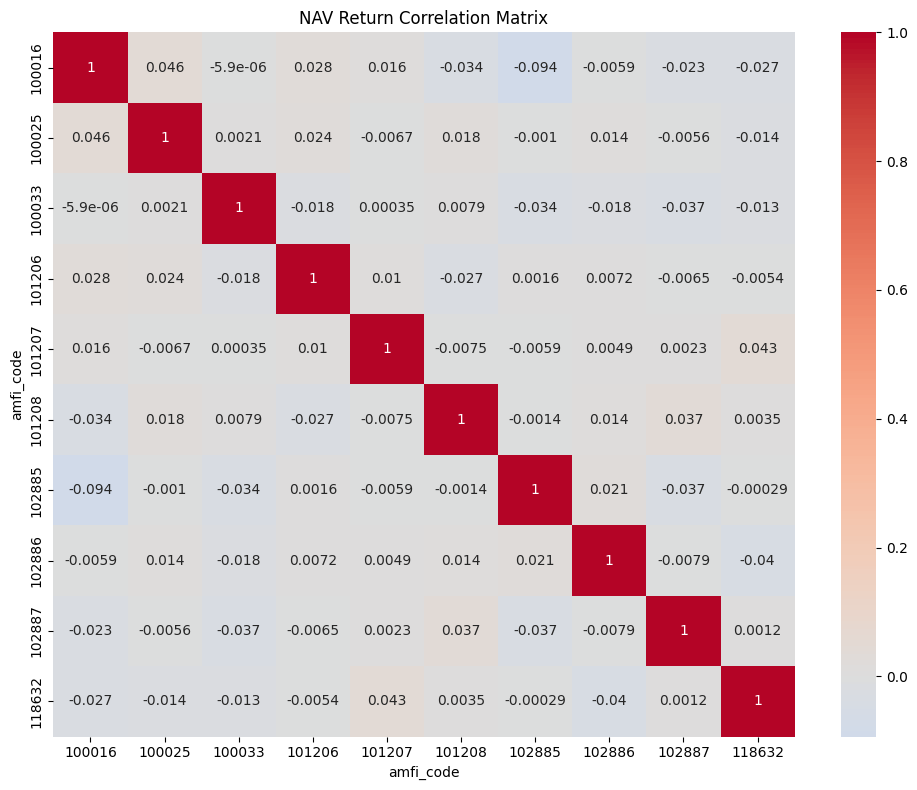

In [86]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    center=0
)

plt.title("NAV Return Correlation Matrix")

plt.tight_layout()

plt.savefig(
    "../reports/charts/nav_correlation_matrix.png",
    bbox_inches="tight"
)

plt.show()

## Insight 11

Most funds exhibit positive correlation in daily returns, indicating that broader market movements influence multiple schemes simultaneously.

In [87]:
portfolio = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

print(portfolio.columns)

portfolio.head()

Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='object')


,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [88]:
sector_data = (
    portfolio.groupby('sector')['weight_pct']
             .sum()
             .sort_values(ascending=False)
)

print(sector_data)

sector
Banking           652.26
IT                455.47
Pharma            407.45
Automobile        323.65
Utilities         265.54
FMCG              229.11
Infrastructure    192.16
Diversified       169.23
Telecom           145.62
Consumer Goods    127.61
NBFC              119.09
Energy            117.91
Cement            105.03
Paints             89.86
Name: weight_pct, dtype: float64


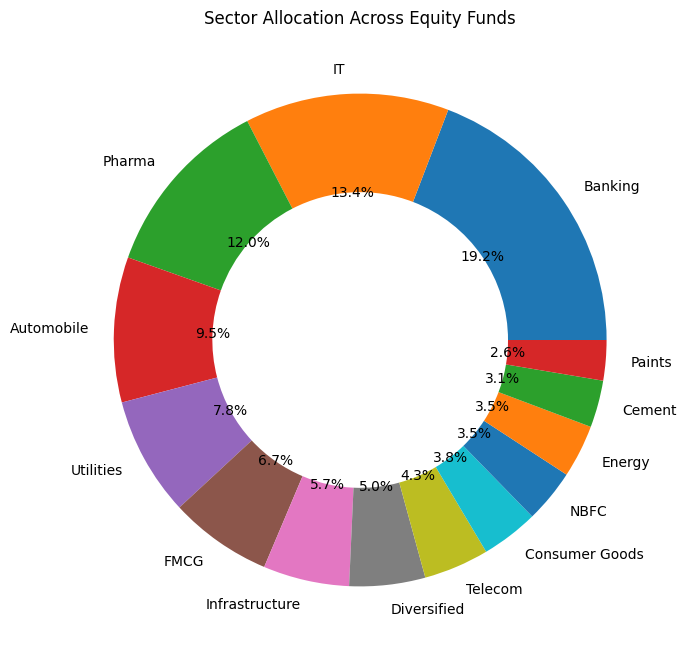

In [89]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))

plt.pie(
    sector_data,
    labels=sector_data.index,
    autopct='%1.1f%%',
    wedgeprops={'width':0.4}
)

plt.title("Sector Allocation Across Equity Funds")

plt.savefig(
    "../reports/charts/sector_allocation.png",
    bbox_inches="tight"
)

plt.show()

## Insight 12

Banking, Pharma, Technology, and Financial Services account for a significant portion of mutual fund equity allocations.

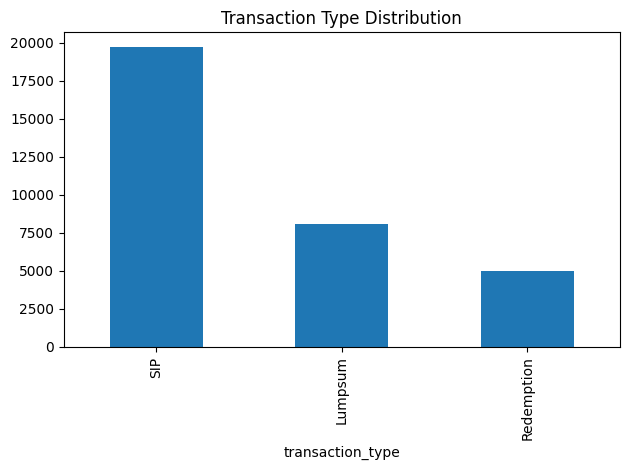

In [90]:
txn['transaction_type'].value_counts().plot(
    kind='bar'
)

plt.title("Transaction Type Distribution")

plt.tight_layout()

plt.savefig(
    "../reports/charts/transaction_type_distribution.png",
    bbox_inches="tight"
)

plt.show()

SIP transactions form a major share of investor activity, indicating preference for systematic investing.

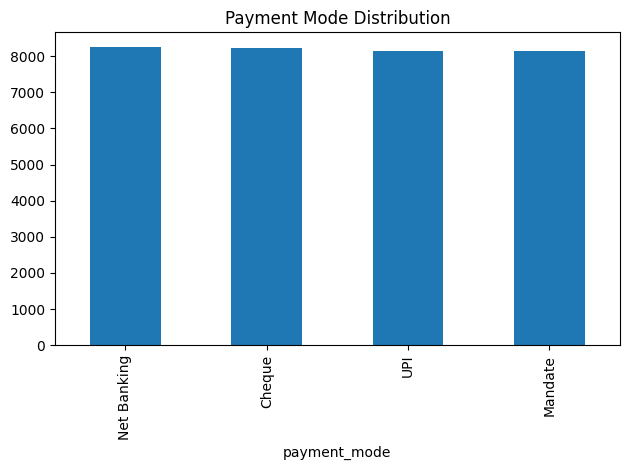

In [91]:
txn['payment_mode'].value_counts().plot(
    kind='bar'
)

plt.title("Payment Mode Distribution")

plt.tight_layout()

plt.savefig(
    "../reports/charts/payment_mode_distribution.png",
    bbox_inches="tight"
)

plt.show()

Digital payment methods dominate mutual fund investments, reflecting increasing fintech adoption.

In [92]:
fund_master = pd.read_csv("C:\\Users\\ABHILASH\\mutual_fund_project\\data\\raw\\01_fund_master.csv")

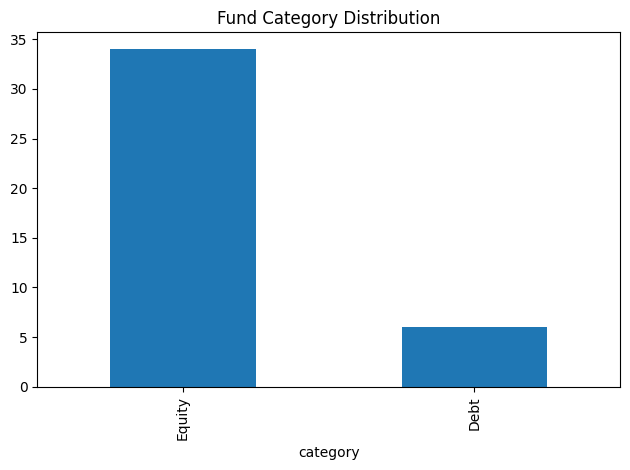

In [93]:
fund_master['category'].value_counts().head(15).plot(
    kind='bar'
)

plt.title("Fund Category Distribution")

plt.tight_layout()

plt.savefig(
    "../reports/charts/fund_category_distribution.png",
    bbox_inches="tight"
)

plt.show()

In [94]:
import os

print(os.listdir("../reports/charts"))

['age_distribution.png', 'age_group_distribution.png', 'amount_boxplot_age_group.png', 'aum_growth.png', 'category_heatmap.png', 'city_tier_split.png', 'correlation_matrix.png', 'folio_growth.png', 'fund_category_distribution.png', 'gender_distribution.png', 'gender_split.png', 'nav_correlation_matrix.png', 'nav_trend.png', 'payment_mode_distribution.png', 'sector_allocation.png', 'sip_inflow.png', 'slip_boxplot.png', 'state_distribution.png', 'state_investment_distribution.png', 't30_b30_distribution.png', 'transaction_type_distribution.png']


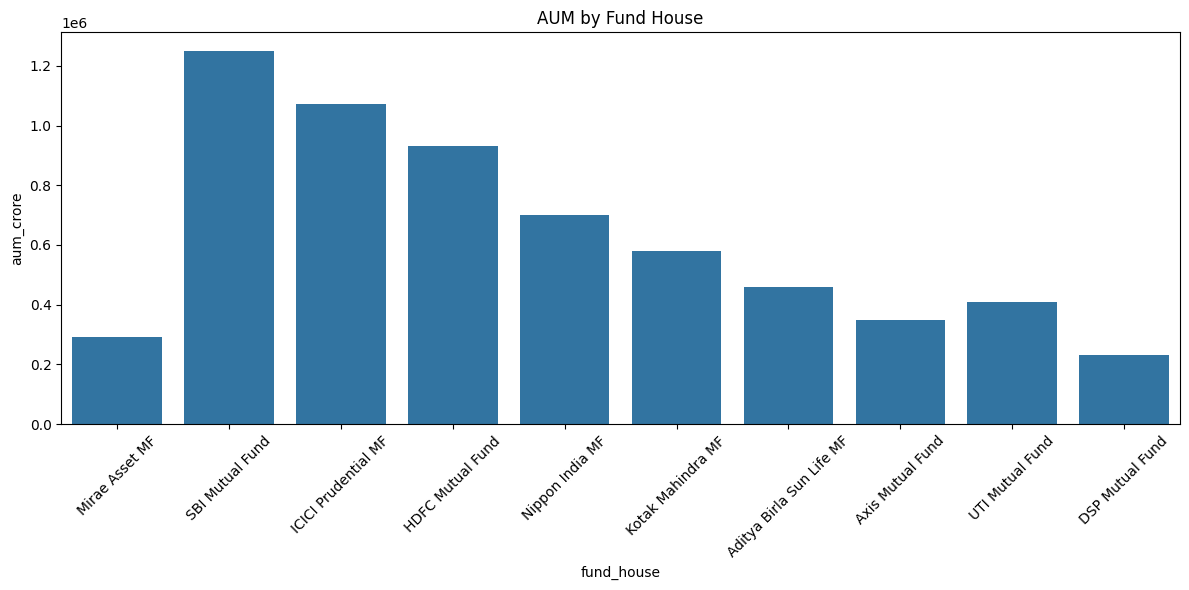

In [96]:
plt.figure(figsize=(12,6))

# your plotting code here
sns.barplot(data=latest_aum, x='fund_house', y='aum_crore')

plt.title("AUM by Fund House")
plt.xticks(rotation=45)
plt.tight_layout()

# SAVE FIRST
plt.savefig(
    "C:\\Users\\ABHILASH\\mutual_fund_project\\reports\\charts\\aum_growth.png",
    bbox_inches="tight",
    dpi=300
)

# THEN SHOW
plt.show()

In [ ]:
plt.figure(figsize=(14,8))

sns.heatmap(
    heatmap_data,
    cmap='YlGnBu'
)

plt.title("Category-wise Net Inflows Heatmap")
plt.tight_layout()

plt.savefig(
    "../reports/charts/category_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

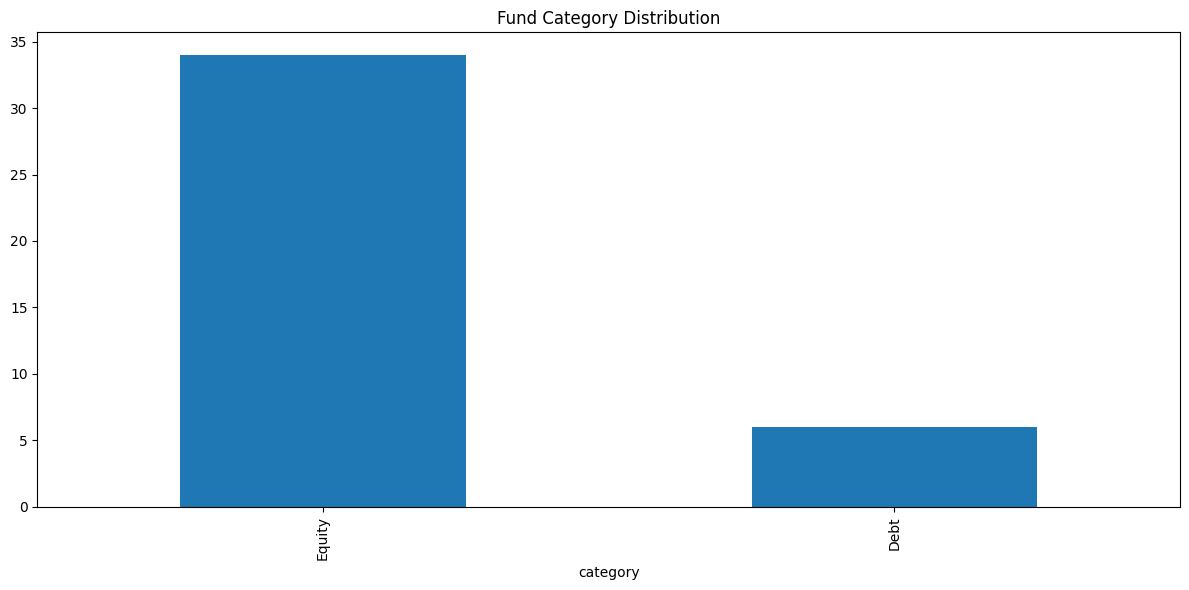

In [98]:
plt.figure(figsize=(12,6))

fund_master['category'].value_counts().head(15).plot(
    kind='bar'
)

plt.title("Fund Category Distribution")
plt.tight_layout()

plt.savefig(
    "C:\\Users\\ABHILASH\\mutual_fund_project\\reports\\charts\\fund_category_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

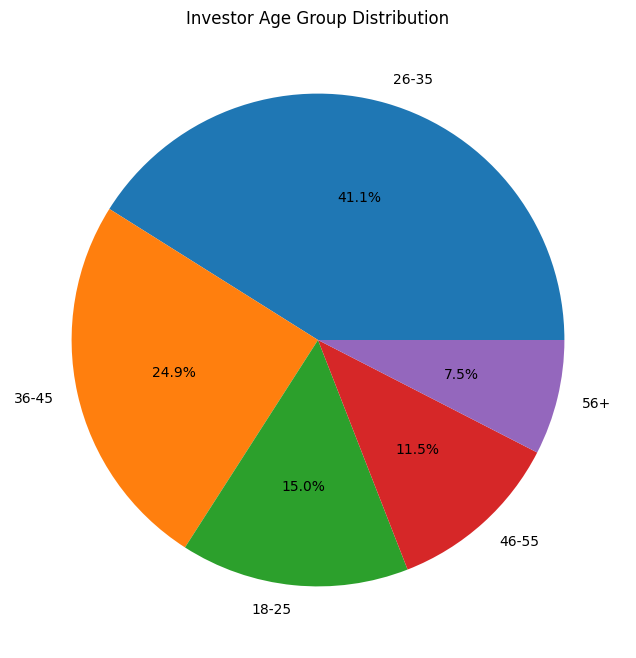

In [99]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))

plt.pie(
    age_counts,
    labels=age_counts.index,
    autopct='%1.1f%%'
)

plt.title("Investor Age Group Distribution")

plt.savefig(
    "C:\\Users\\ABHILASH\\mutual_fund_project\\reports\\charts\\age_group_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [100]:
nav_pivot = nav.pivot(
    index='date',
    columns='amfi_code',
    values='nav'
)

In [101]:
nav_pivot = nav_pivot.iloc[:, :10]

In [102]:
returns = nav_pivot.pct_change()

In [103]:
corr_matrix = returns.corr()

print(corr_matrix.head())

amfi_code    100016    100025    100033    101206    101207    101208  \
amfi_code                                                               
100016     1.000000  0.045567 -0.000006  0.027747  0.016053 -0.033773   
100025     0.045567  1.000000  0.002150  0.023769 -0.006710  0.018455   
100033    -0.000006  0.002150  1.000000 -0.018079  0.000351  0.007864   
101206     0.027747  0.023769 -0.018079  1.000000  0.010202 -0.027230   
101207     0.016053 -0.006710  0.000351  0.010202  1.000000 -0.007530   

amfi_code    102885    102886    102887    118632  
amfi_code                                          
100016    -0.093533 -0.005867 -0.023316 -0.026781  
100025    -0.001038  0.013754 -0.005648 -0.014166  
100033    -0.034228 -0.018166 -0.036647 -0.013318  
101206     0.001570  0.007229 -0.006490 -0.005432  
101207    -0.005929  0.004860  0.002304  0.043384  


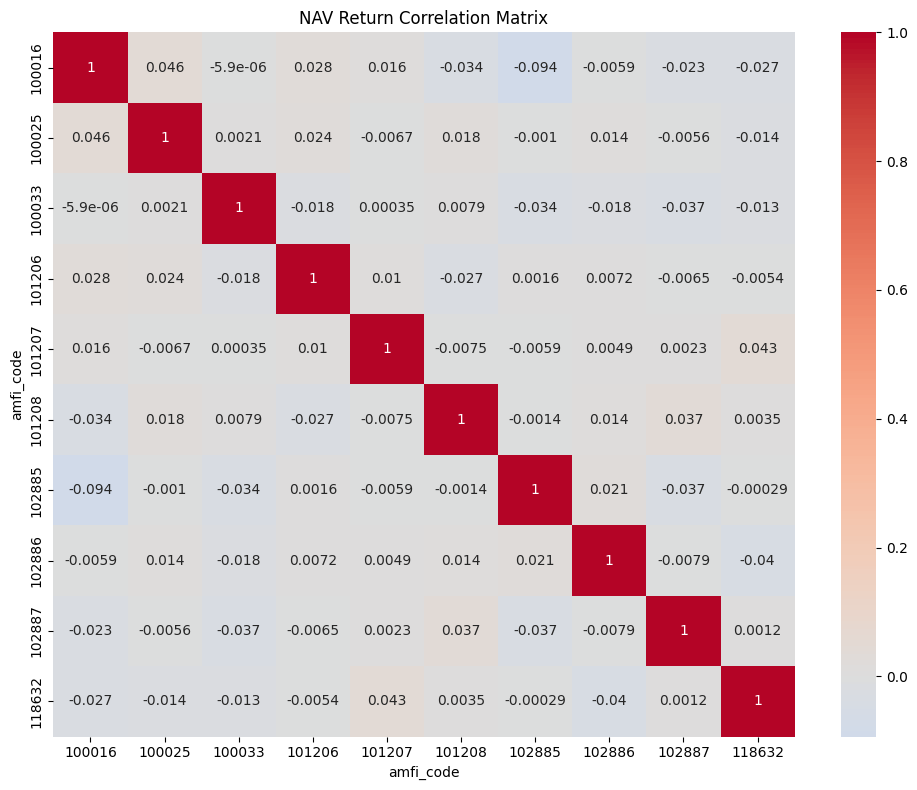

In [104]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    center=0
)

plt.title("NAV Return Correlation Matrix")

plt.tight_layout()

plt.savefig(
    "../reports/charts/nav_correlation_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()